## BREAST CANCER GRAPHICS  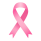

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))
from values.cleaning import prepare_data

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import joblib

model = joblib.load("models/random_forest.pkl")

In [14]:
column_names = [
    "id","diagnosis",
    "radius_mean","texture_mean","perimeter_mean","area_mean","smoothness_mean",
    "compactness_mean","concavity_mean","concave_points_mean","symmetry_mean","fractal_dimension_mean",
    "radius_se","texture_se","perimeter_se","area_se","smoothness_se",
    "compactness_se","concavity_se","concave_points_se","symmetry_se","fractal_dimension_se",
    "radius_worst","texture_worst","perimeter_worst","area_worst","smoothness_worst",
    "compactness_worst","concavity_worst","concave_points_worst","symmetry_worst","fractal_dimension_worst"
]

df = pd.read_csv(
    "../data/breast+cancer+wisconsin+diagnostic/wdbc.data",
    sep=",",
    header=None,
    names=column_names
)

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [16]:
print(df.shape)
print(df["diagnosis"].value_counts())

(569, 32)
diagnosis
B    357
M    212
Name: count, dtype: int64


In [17]:
X, y = prepare_data(df)

print(type(X))
print(type(y))
print(len(X), len(y))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
569 569


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

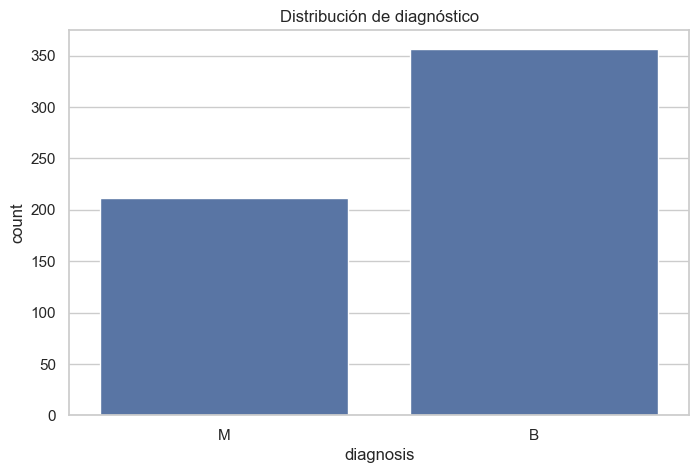

In [24]:
#Variable objetivo 
sns.countplot(x="diagnosis", data=df)
plt.title("Distribución de diagnóstico")
plt.show()

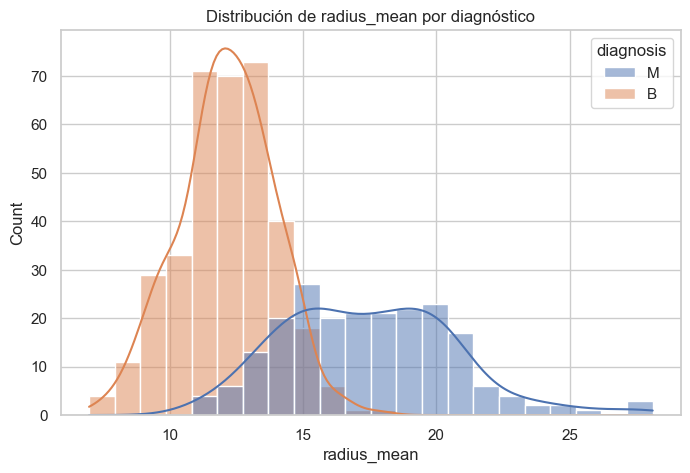

In [25]:
#HISTOGRAMA 
sns.histplot(data=df, x="radius_mean", hue="diagnosis", kde=True)
plt.title("Distribución de radius_mean por diagnóstico")
plt.show()

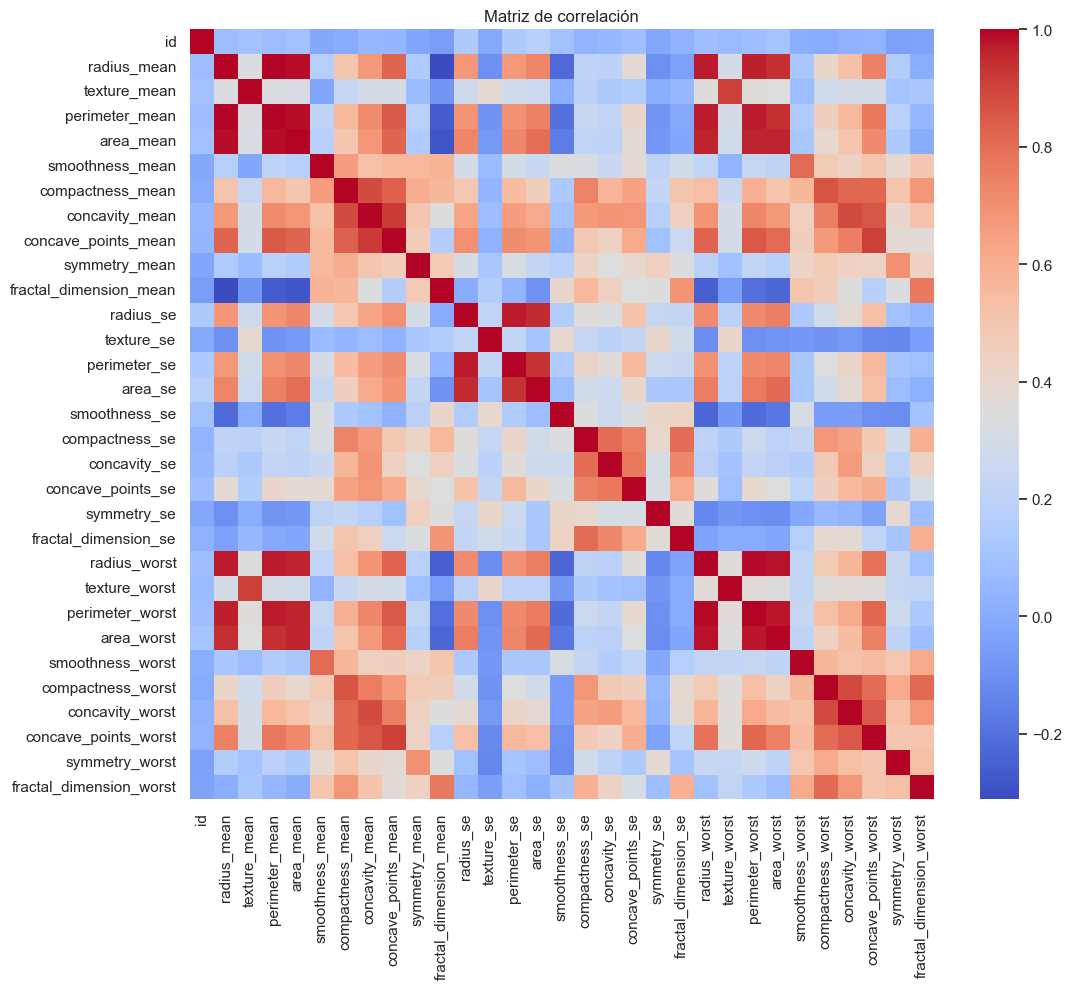

In [28]:
#Matriz de correlación
plt.figure(figsize=(12,10))
sns.heatmap(df.select_dtypes(include="number").corr(), cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

# CLASS DISTRIBUTION

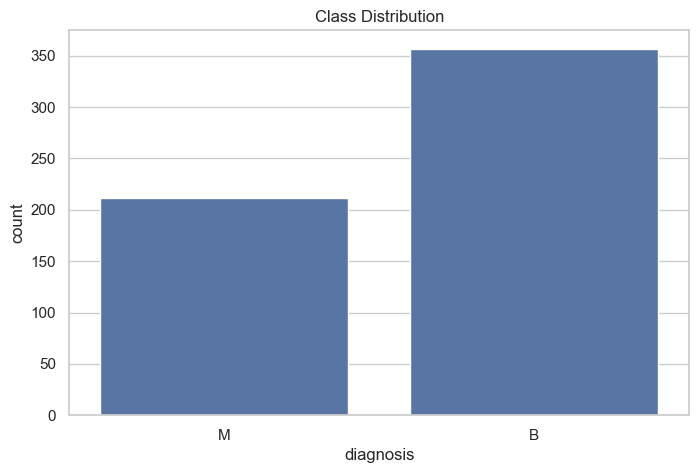

diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64


In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="diagnosis", data=df)
plt.title("Class Distribution")
plt.show()

print(df["diagnosis"].value_counts(normalize=True))

# QUICK EDA

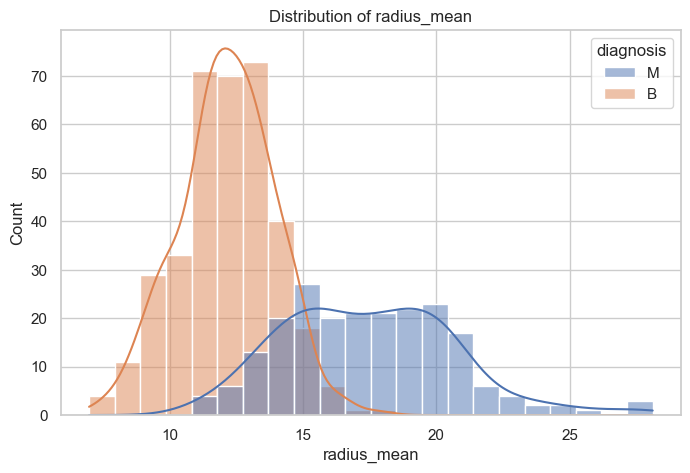

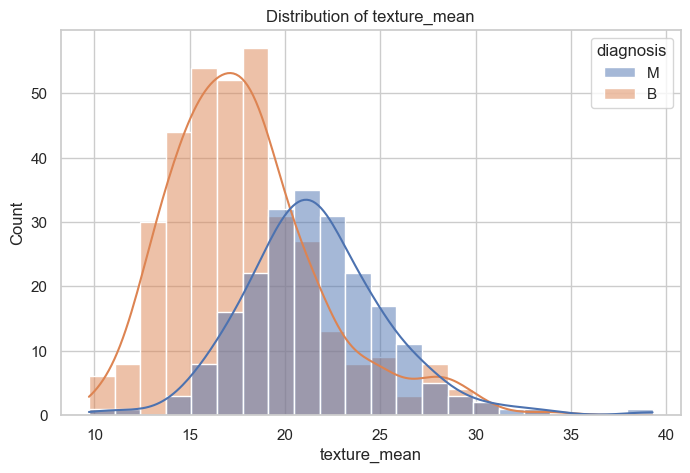

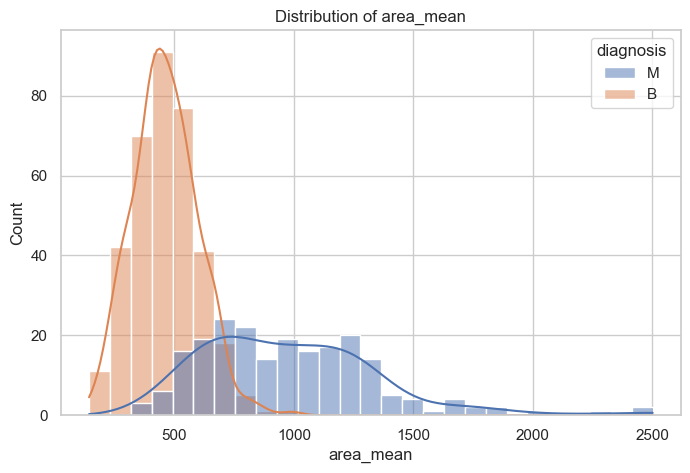

In [30]:
features = ["radius_mean", "texture_mean", "area_mean"]

for col in features:
    sns.histplot(data=df, x=col, hue="diagnosis", kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# Comparativo 

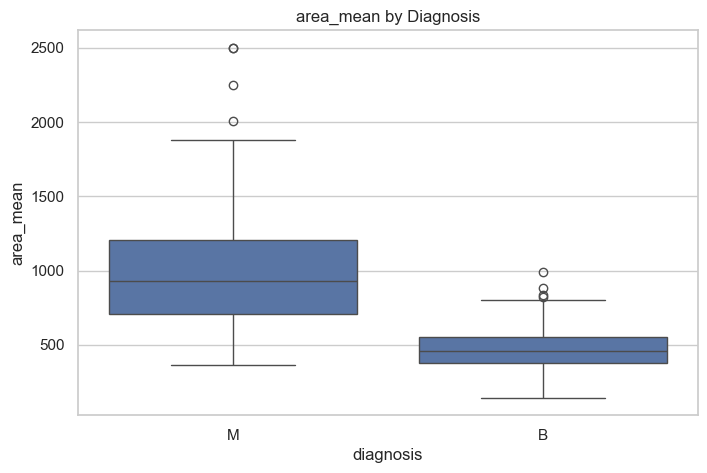

In [31]:
sns.boxplot(x="diagnosis", y="area_mean", data=df)
plt.title("area_mean by Diagnosis")
plt.show()

# KNN 

In [32]:
X, y = prepare_data(df)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [33]:
#Entrenando KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

print("KNN Accuracy:", knn.score(X_test, y_test))

KNN Accuracy: 0.956140350877193


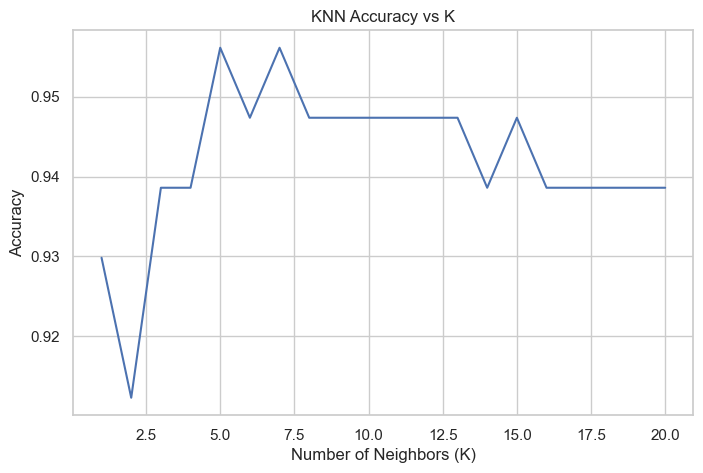

In [40]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

k_values = range(1, 21)
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    scores.append(knn.score(X_test, y_test))

plt.plot(k_values, scores)
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.show()

# CONFUSION MATRIX

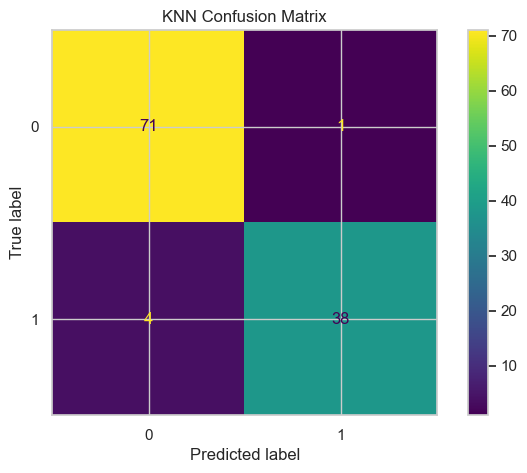

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = knn.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("KNN Confusion Matrix")
plt.show()

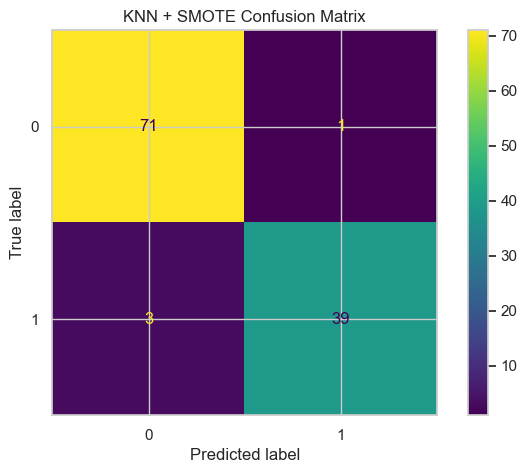

In [45]:
knn_smote = KNeighborsClassifier(n_neighbors=5)
knn_smote.fit(X_res, y_res)

y_pred_smote = knn_smote.predict(X_test)

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_smote)
plt.title("KNN + SMOTE Confusion Matrix")
plt.show()

# DECISION TREE

In [37]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

print("Decision Tree Accuracy:", dt.score(X_test, y_test))

Decision Tree Accuracy: 0.9298245614035088


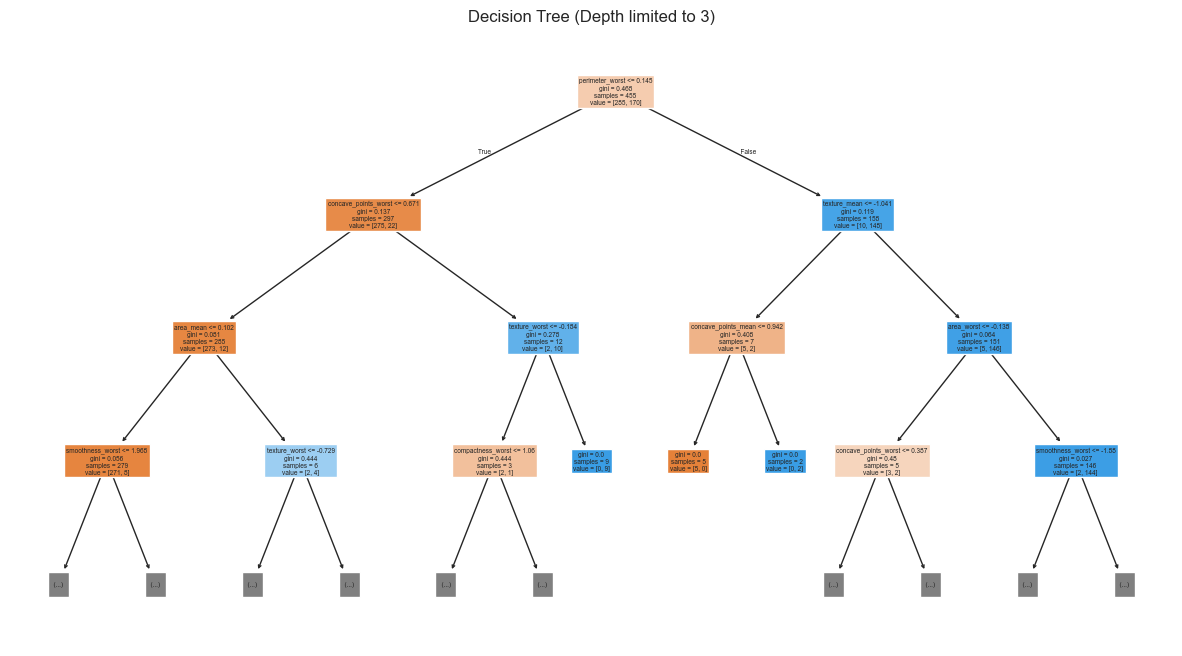

In [41]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15,8))
plot_tree(dt, filled=True, max_depth=3, feature_names=X.columns)
plt.title("Decision Tree (Depth limited to 3)")
plt.show()

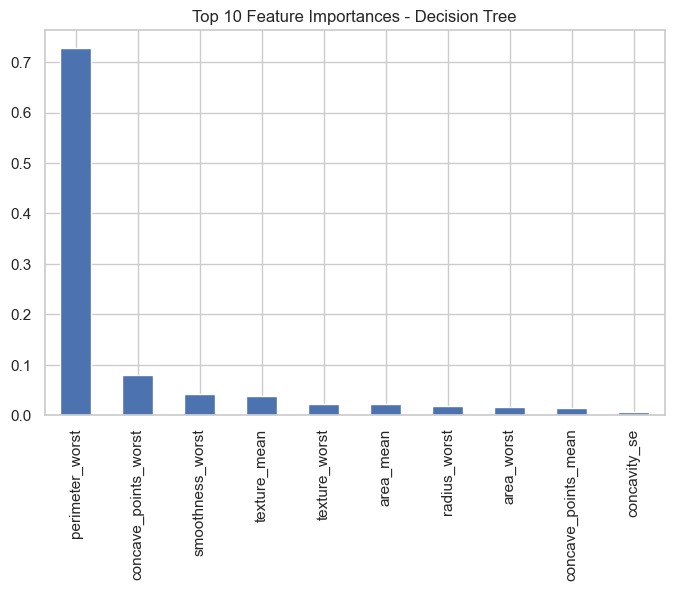

In [42]:
import pandas as pd

importances = pd.Series(dt.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

importances.head(10).plot(kind="bar")
plt.title("Top 10 Feature Importances - Decision Tree")
plt.show()

# OVERSAMPLING

In [38]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

print("After Oversampling:", y_res.value_counts())

After Oversampling: diagnosis
1    285
0    285
Name: count, dtype: int64


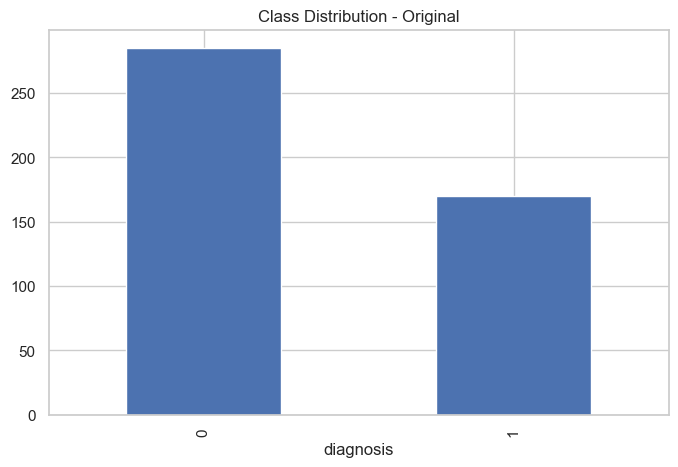

In [43]:
y_train.value_counts().plot(kind="bar")
plt.title("Class Distribution - Original")
plt.show()

# UNDERSAMPLING

In [39]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_res_u, y_res_u = rus.fit_resample(X_train, y_train)

print("After Undersampling:", y_res_u.value_counts())

After Undersampling: diagnosis
0    170
1    170
Name: count, dtype: int64


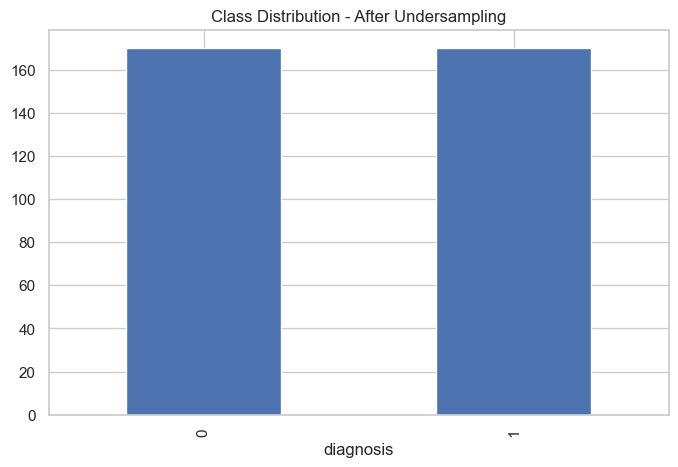

In [44]:
pd.Series(y_res_u).value_counts().plot(kind="bar")
plt.title("Class Distribution - After Undersampling")
plt.show()